In [27]:
from agent_framework import Agent, Content, Message
from pathlib import Path
from agent_framework.foundry import FoundryChatClient
from azure.identity import AzureCliCredential

In [28]:
import os
import base64
import mimetypes
from dotenv import load_dotenv

In [29]:
load_dotenv()

True

In [30]:
client = FoundryChatClient(credential=AzureCliCredential())

In [31]:
agent = Agent(
    client=client,
    name="VisionAgent",
    instructions="You are a image analysist, you get a image and need to respond with what you see in the picture.",
)

In [32]:
def create_sample_image(image_name: str) -> tuple[str, str]:
    image_path = Path("../../files") / image_name
    mime_type, _ = mimetypes.guess_type(image_path.name)
    supported_mime_types = {"image/png", "image/jpeg"}

    if mime_type not in supported_mime_types:
        raise ValueError(f"Unsupported image type '{mime_type}' for {image_path.name}. Use PNG or JPEG images.")

    with image_path.open("rb") as image_file:
        image_b64 = base64.b64encode(image_file.read()).decode("utf-8")
    image_uri = f"data:{mime_type};base64,{image_b64}"
    return image_uri, mime_type

image/png
8494


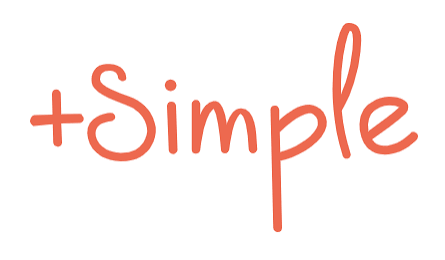

In [39]:
image_uri, image_media_type = create_sample_image("images.png")
message = Message(
    role="user",
    contents=[
        Content.from_text(text="What's in this image?"),
        Content.from_uri(uri=image_uri, media_type=image_media_type),
    ],
)
print(image_media_type)
print(len(image_uri))
print(image_uri)

In [40]:
result = await agent.run(message)

In [41]:
print(result.text)

The image shows a white background with a coral/orange handwritten-style wordmark reading "+Simple" (a plus sign immediately before the word "Simple"). It looks like a logo or stylized text in a casual script font.
